# 03. 기준선 — 모델 계약을 먼저 얼리고, 내용물은 나중에 바꾼다

> **「만약의 감독」 분석 노트북 (00~09 중 03장)** · 설계 정본: [ML_설계_v1_0.md](../docs/planning/ml/version1.0/ML_설계_v1_0.md) §4~§6 · [피처_정의서_v1_0.md](../docs/planning/ml/version1.0/피처_정의서_v1_0.md) §4 · [평가_설계_v1_0.md](../docs/planning/ml/version1.0/평가_설계_v1_0.md) §1~§3

## 이 장의 질문

1. **결과 확률 모델의 기준선**(Elo 차이 로지스틱)은 방어선 RPS 0.19~0.22 안에 들어오는가?
2. **스코어 모델**(포아송 λ 쌍 + Dixon-Coles τ)의 계수와 ρ를 학습 데이터에서 뽑을 수 있는가?
3. 두 모델을 **브라우저까지 보내는 계약**(ONNX 입력 시그니처 · 계수 JSON)을 지금 확정해도
   06장의 GBDT 앙상블이 그 계약 안에 들어오는가?
4. 데이터에 존재하지 않는 전술 입력(슬라이더·배치)을 다루는 **조정 계층**의 상수
   δ·κ·ρ·c를 민감도 목표 밴드(±3~8%p)에 맞출 수 있는가?

## 이 장이 특별한 이유 — 노트북이 아니라 **계약서**다

03~09장은 모델을 좋게 만드는 장이지만, 03장만은 **프론트엔드를 먼저 풀어주는 장**입니다.
구현 계획(B3)의 전략은 "모델 파일의 계약을 1일차에 확정하고 내용물은 나중에 교체한다"이고,
그 계약이 이 장의 §8~§9 산출물입니다. 06장의 GBDT 앙상블은 **같은 입력 시그니처·같은
파일 경로**로 `public/model/`을 덮어쓰기만 하면 되고 프론트엔드 코드는 건드리지 않습니다.

기준선 배포는 임시방편이 아닙니다 — [ML_설계 §7.1](../docs/planning/ml/version1.0/ML_설계_v1_0.md)의
폴백 2단이 "앙상블 → 단일 GBDT → 로지스틱 기준선"을 정당한 강등 경로로 이미 명시했으므로,
이 장의 산출물은 **문서화된 최저 보장선**입니다.

## 개정 이력 (반복 사이클 규약 — 정본: [ITERATION-LOG](ITERATION-LOG.md))

| 사이클 | 날짜 | 발견 | 원인 | 수정 | 영향 범위 |
|---|---|---|---|---|---|
| c3 | 2026-07-27 | 최초 작성 (B3) — ① 02장이 남긴 "신생팀 초기값 1500" 재검 과제 ② `home/away` 지정이 중립 경기 서비스에 그대로 쓰이면 한국에 근거 없는 이점이 붙음 ③ 템포 슬라이더가 λ 비율을 바꾸지 않아 F04 GWT("4종 각각 확률 변화")를 Δ_eff 경로만으로는 못 지킴 | 피처는 대회 데이터의 `home_team` 관례(선명 팀)를 그대로 상속했고, 조정 계층 §4.1은 λ→확률 반영 경로를 Δ_eff 하나로만 적었음 | §2.1 방향 대칭 실측 후 **미러 증강 학습** 채택 · §6.4 **무승부 몫 채널** 신설로 템포를 확률에 연결 · §7에서 cze 초기값 문제 실측 해소 | 이 장 전체 · `public/model/` 계약 · 06장은 이 계약을 상속 · vNEXT 변경노트 2건 |

## 규약

00~02장과 동일(시드 42 · Decision Box · pandera 계약 · 입력 게이트).
**test=2022는 이 장에서 열지 않습니다** — 평가_설계 §3의 "최종 평가 1회"는 06장 평가
게이트에 예약되어 있습니다. 이 장의 모든 수치는 valid=2018 기준입니다.

In [1]:
import sys, platform, random, json, bisect, hashlib, warnings
from collections import defaultdict
from datetime import date, datetime, timezone, timedelta
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize, minimize_scalar

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

# 한글 폰트 — 00~02장과 동일 (디자인 시스템 폰트 우선)
matplotlib.rcParams["font.family"] = ["Pretendard", "Malgun Gothic", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_INTERIM = ROOT / "data" / "interim"
DATA_FEAT = ROOT / "data" / "features"
FIGURES = ROOT / "notebooks" / "figures"
PUBLIC_MODEL = ROOT / "public" / "model"
FIXTURES = ROOT / "tests" / "fixtures"
for d in (PUBLIC_MODEL, FIXTURES):
    d.mkdir(parents=True, exist_ok=True)

KST = timezone(timedelta(hours=9))
print(f"Python {sys.version.split()[0]} on {platform.system()}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | scipy {stats.__name__ and __import__('scipy').__version__}")
import sklearn, skl2onnx, onnx, onnxruntime
print(f"scikit-learn {sklearn.__version__} | skl2onnx {skl2onnx.__version__} | onnx {onnx.__version__} | onnxruntime {onnxruntime.__version__}")
print(f"SEED = {SEED} | ROOT = {ROOT.name}")

Python 3.12.13 on Windows
pandas 3.0.3 | numpy 1.26.4 | scipy 1.17.1


scikit-learn 1.9.0 | skl2onnx 1.20.0 | onnx 1.22.0 | onnxruntime 1.20.1
SEED = 42 | ROOT = world-cup-tactics-planning-35e01b


## 0. 입력 게이트 — 02장 인계 조건 확인

02장 말미가 명시한 인계 조건은 세 가지입니다: `features_v1` 존재 · 리키지 ①③ 통과 ·
분할 마스크(≤2014 / 2018 / 2022) 정의. 여기서 기계적으로 재확인하고, **실명 컬럼 0개**를
한 번 더 검사합니다(NB-R1은 장마다 반복합니다 — 검사 비용이 사고 비용보다 싸기 때문입니다).

In [2]:
feat_path = DATA_FEAT / "features_v1.parquet"
assert feat_path.exists(), "features_v1.parquet 없음 — 02장을 먼저 실행하세요"
df = pd.read_parquet(feat_path)

NAME_KEYS = ("given_name", "family_name", "player_name", "full_name", "shirt_name")
assert not any(any(k in c.lower() for k in NAME_KEYS) for c in df.columns), "실명 컬럼 검출"

TRAIN, VALID, TEST = df["year"] <= 2014, df["year"] == 2018, df["year"] == 2022
assert TRAIN.sum() + VALID.sum() + TEST.sum() == len(df), "분할이 전체를 덮지 않음"
assert not (TRAIN & VALID).any() and not (VALID & TEST).any() and not (TRAIN & TEST).any()
assert df.loc[TRAIN, "year"].max() <= 2014 < df.loc[VALID, "year"].min(), "시간 순서 위반"

print(f"features_v1: {df.shape[0]}행 × {df.shape[1]}열 · 실명 컬럼 0개")
print(f"분할 — train {TRAIN.sum()} (≤2014) / valid {VALID.sum()} (2018) / test {TEST.sum()} (2022, 이 장에서 미사용)")
print(f"라벨 분포(train): {df.loc[TRAIN, 'label90'].value_counts(normalize=True).round(4).to_dict()}")

features_v1: 964행 × 26열 · 실명 컬럼 0개
분할 — train 836 (≤2014) / valid 64 (2018) / test 64 (2022, 이 장에서 미사용)
라벨 분포(train): {'home_win': 0.5371, 'draw': 0.2596, 'away_win': 0.2033}


### Decision Box DB-05 — 모델 계약(무엇을 얼리는가)

| 항목 | 이 장의 확정 | 근거·파급 |
|---|---|---|
| 입력 벡터 | **10원소 float32 고정 순서** (§1) — `elo_diff` + 자기 4 + 상대 4 + `stage_ko` | 06장 GBDT가 같은 벡터를 먹는다. 프론트는 순서만 알면 된다 |
| 관점 | 항상 **"자기(self) = 화면의 우리 팀"** — 학습의 home/away 지정을 서비스에 상속하지 않는다 | §2.1 실측: 상속하면 Δ=0에서 승 0.50 vs 패 0.22 |
| 출력 | `probabilities` float32 `[N,3]` = **[승, 무, 패]** | Worker 계약(ML_설계 §6.1)의 `p: [number, number, number]` |
| 파일 경로 | `public/model/outcome.onnx` · `public/model/score-params.json` | 06장은 **덮어쓰기만** 한다 |
| 스코어 모델 | ONNX 변환하지 않고 **계수 JSON** — JS에서 닫힌 수식 계산 | ADR-006 · 변환 리스크를 주선 1개로 축소 |
| test=2022 | **이 장에서 열지 않음** | 평가_설계 §3 "최종 평가 1회"는 06장 예약 |

## 1. 입력 벡터 고정 — 왜 `elo_diff` 하나가 아닌가

계획서의 기준선은 "Elo 차이 covariate 로지스틱"입니다. 그런데 **배포되는 ONNX의 입력
시그니처**를 `elo_diff` 1원소로 얼리면, 06장의 GBDT가 폼·경험·개최국을 쓰는 순간 계약이
깨지고 프론트엔드를 다시 손대야 합니다. 계약 동결의 목적이 정확히 그것을 막는 것이므로,
**입력 벡터는 피처_정의서 §2 카탈로그 전체로 얼리고**, "Elo 단독 로지스틱"은 §2.2에서
**비교 기준선**으로 측정만 합니다.

`stage_ko`는 features_v1에 `h_`·`a_` 두 벌로 있지만 두 값이 항상 같습니다(경기 속성이지
팀 속성이 아님). 계약에는 **1개만** 넣습니다 — 계약에 중복을 넣으면 06장이 그 중복을
영원히 상속합니다.

In [3]:
assert (df["h_stage_ko"] == df["a_stage_ko"]).all(), "stage_ko가 팀별로 다름 — 가정 붕괴"

SELF_FEATS = ["form_pts", "form_gd", "exp_apps", "host"]
FEATURE_ORDER = (
    ["elo_diff"]
    + [f"self_{c}" for c in SELF_FEATS]
    + [f"opp_{c}" for c in SELF_FEATS]
    + ["stage_ko"]
)
N_FEAT = len(FEATURE_ORDER)
CLASS_ORDER = ["win", "draw", "lose"]   # 자기(self) 관점


def to_contract(d: pd.DataFrame, flip: bool = False) -> np.ndarray:
    """features_v1 행 → 계약 벡터. flip=True면 away 팀을 '자기'로 본다 (미러)."""
    s, o = ("a_", "h_") if flip else ("h_", "a_")
    sign = -1.0 if flip else 1.0
    cols = [sign * d["elo_diff"].to_numpy(float)]
    cols += [d[s + c].to_numpy(float) for c in SELF_FEATS]
    cols += [d[o + c].to_numpy(float) for c in SELF_FEATS]
    cols += [d["h_stage_ko"].to_numpy(float)]
    return np.column_stack(cols)


def to_label(d: pd.DataFrame, flip: bool = False) -> np.ndarray:
    m = {"home_win": 0, "draw": 1, "away_win": 2} if not flip else {"home_win": 2, "draw": 1, "away_win": 0}
    return d["label90"].map(m).to_numpy()


print("계약 벡터 순서 (%d원소):" % N_FEAT)
for i, name in enumerate(FEATURE_ORDER):
    print(f"  [{i}] {name}")
print("출력 클래스 순서:", CLASS_ORDER)

계약 벡터 순서 (10원소):
  [0] elo_diff
  [1] self_form_pts
  [2] self_form_gd
  [3] self_exp_apps
  [4] self_host
  [5] opp_form_pts
  [6] opp_form_gd
  [7] opp_exp_apps
  [8] opp_host
  [9] stage_ko
출력 클래스 순서: ['win', 'draw', 'lose']


## 2. 결과 확률 모델 — 로지스틱 기준선

### 2.1 먼저 확인할 것: 학습 데이터의 `home` 지정은 서비스에서 무엇을 뜻하는가

월드컵 경기 대부분은 중립 개최지입니다. 그럼에도 데이터셋은 각 경기에 `home_team`을
지정하는데(관례적으로 조 편성상 선명 팀), 이 지정에는 **경기장 이점이 아닌 편성 관행이**
섞여 있습니다. 서비스는 한국을 화면의 "우리 팀"으로 놓으므로, 만약 이 지정을 그대로
상속하면 한국이 근거 없는 이점을 무료로 얻습니다.

실측으로 먼저 크기를 봅니다 — 크기가 작으면 무시하고, 크면 구조로 없애야 합니다.

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def rps(p: np.ndarray, y: np.ndarray) -> float:
    """Ranked Probability Score — 평가_설계 §2.1 (낮을수록 좋음)"""
    o = np.zeros_like(p)
    o[np.arange(len(y)), y] = 1.0
    return float(np.mean(np.sum((np.cumsum(p, 1) - np.cumsum(o, 1))[:, :2] ** 2, 1) / 2))


Xva, yva = to_contract(df[VALID]), to_label(df[VALID])
Xtr_nat, ytr_nat = to_contract(df[TRAIN]), to_label(df[TRAIN])

probe = LogisticRegression(max_iter=2000).fit(df.loc[TRAIN, ["elo_diff"]].to_numpy(), ytr_nat)
p_even = probe.predict_proba([[0.0]]).ravel()
print("Elo 동률(Δ=0)에서 'home' 지정만으로 생기는 확률 —")
print("  승 %.4f / 무 %.4f / 패 %.4f  → 승−패 격차 %+.1f%%p" % (*p_even, 100 * (p_even[0] - p_even[2])))
print("  train 라벨 기저율 승 %.3f / 무 %.3f / 패 %.3f" % tuple(np.bincount(ytr_nat, minlength=3) / len(ytr_nat)))

Elo 동률(Δ=0)에서 'home' 지정만으로 생기는 확률 —
  승 0.5011 / 무 0.2824 / 패 0.2165  → 승−패 격차 +28.5%p
  train 라벨 기저율 승 0.537 / 무 0.260 / 패 0.203


격차가 **28%p**입니다. 무시할 크기가 아니므로 구조로 제거합니다.

**채택: 미러 증강 학습** `[설계 결정]` — 학습 행마다 자기/상대를 뒤집은 행을 함께
넣습니다(`elo_diff` 부호 반전 · 자기↔상대 피처 교환 · 승↔패 라벨 교환). 그러면 학습된
함수가 구조적으로 `p_승(x) = p_패(mirror(x))`를 만족해 **방향이 공짜 이점을 주지 못합니다.**

기각한 대안: ① 지정 그대로 사용 — 서비스가 한국을 항상 home에 놓으므로 편향 상속
② `home` 더미 피처 추가 후 런타임에 0 대입 — 학습 시 관측되지 않은 조합(양팀 모두 away)을
외삽하게 되어 근거가 약함. 미러 증강은 외삽 없이 같은 목적을 달성합니다.

비용도 확인합니다 — 대칭화가 valid 성능을 깎는다면 트레이드오프를 문서에 적어야 합니다.

In [5]:
Xtr_mir = np.vstack([Xtr_nat, to_contract(df[TRAIN], flip=True)])
ytr_mir = np.concatenate([ytr_nat, to_label(df[TRAIN], flip=True)])


def fit_logistic(X, y):
    return Pipeline([("scale", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))]).fit(X, y)


elo_idx = [FEATURE_ORDER.index("elo_diff")]
cands = {
    "① Elo 단독 · 자연 방향": (fit_logistic(Xtr_nat[:, elo_idx], ytr_nat), elo_idx),
    "② Elo 단독 · 미러 증강": (fit_logistic(Xtr_mir[:, elo_idx], ytr_mir), elo_idx),
    "③ 전 피처 · 자연 방향": (fit_logistic(Xtr_nat, ytr_nat), slice(None)),
    "④ 전 피처 · 미러 증강": (fit_logistic(Xtr_mir, ytr_mir), slice(None)),
}
rows = []
for name, (mdl, sel) in cands.items():
    pv = mdl.predict_proba(Xva[:, sel])
    rows.append({
        "후보": name,
        "valid RPS": round(rps(pv, yva), 4),
        "valid 정확도": round(float((pv.argmax(1) == yva).mean()), 4),
        "Δ=0 승−패": round(float(np.diff(mdl.predict_proba(np.zeros((1, Xva[:, sel].shape[1])))[0, [2, 0]])[0]), 4),
    })
base_rate = np.bincount(ytr_nat, minlength=3) / len(ytr_nat)
rows.append({
    "후보": "⓪ 기저율 고정(참고)",
    "valid RPS": round(rps(np.tile(base_rate, (len(yva), 1)), yva), 4),
    "valid 정확도": round(float((np.full(len(yva), base_rate.argmax()) == yva).mean()), 4),
    "Δ=0 승−패": round(float(base_rate[0] - base_rate[2]), 4),
})
compare = pd.DataFrame(rows)
print(compare.to_string(index=False))
print("\n방어선(평가_설계 §1): RPS 0.19~0.22 · 정확도 0.50~0.55")

              후보  valid RPS  valid 정확도  Δ=0 승−패
① Elo 단독 · 자연 방향     0.2241     0.5312   0.2845
② Elo 단독 · 미러 증강     0.2044     0.5469  -0.0000
  ③ 전 피처 · 자연 방향     0.2096     0.5000   0.4093
  ④ 전 피처 · 미러 증강     0.1975     0.4844  -0.0000
    ⓪ 기저율 고정(참고)     0.2663     0.3906   0.3337

방어선(평가_설계 §1): RPS 0.19~0.22 · 정확도 0.50~0.55


### 2.2 채택과 그 근거

미러 증강은 **비용이 아니라 이득**이었습니다 — valid RPS가 양쪽 후보 모두에서 개선됩니다.
해석: `home` 지정이 담고 있던 신호는 2018 대회로 일반화되지 않는 **표본 특유의 편향**에
가까웠고, 대칭화가 그 편향을 제거하면서 동시에 학습 표본을 2배로 늘렸습니다.

따라서 **④ 전 피처 · 미러 증강**을 배포 모델로 확정합니다. ①은 P12 공개 실측과 같은
자리의 "Elo 단독 기준선"이므로 비교 수치로만 보고합니다.

In [6]:
model = cands["④ 전 피처 · 미러 증강"][0]
p_valid = model.predict_proba(Xva)
VALID_RPS = rps(p_valid, yva)
VALID_ACC = float((p_valid.argmax(1) == yva).mean())
ELO_ONLY_RPS = float(compare.loc[compare["후보"] == "① Elo 단독 · 자연 방향", "valid RPS"].iloc[0])

# 대칭성 검증 — 계약이 약속한 성질이 실제로 성립하는가
Xchk = Xva[:8].copy()
Xmir = to_contract(df[VALID].iloc[:8], flip=True)
sym_err = float(np.abs(model.predict_proba(Xchk) - model.predict_proba(Xmir)[:, ::-1]).max())
print("배포 모델 — valid RPS %.4f · 정확도 %.4f" % (VALID_RPS, VALID_ACC))
print("비교 기준선(Elo 단독·자연 방향) valid RPS %.4f" % ELO_ONLY_RPS)
print("방향 대칭성 최대 오차 %.2e (p_승(x) = p_패(mirror x))" % sym_err)
assert sym_err < 1e-6, "미러 증강이 대칭을 만들지 못함"
print("\n방어선 대조 — RPS %s (0.19~0.22) · 정확도 %s (0.50~0.55)" % (
    "충족" if 0.19 <= VALID_RPS <= 0.22 else "이탈",
    "충족" if 0.50 <= VALID_ACC <= 0.55 else "이탈"))
print("※ 이 수치는 valid=2018 기준입니다. 방어선의 최종 대조는 test=2022로 06장에서 1회만 합니다.")

배포 모델 — valid RPS 0.1975 · 정확도 0.4844
비교 기준선(Elo 단독·자연 방향) valid RPS 0.2241
방향 대칭성 최대 오차 2.99e-14 (p_승(x) = p_패(mirror x))

방어선 대조 — RPS 충족 (0.19~0.22) · 정확도 이탈 (0.50~0.55)
※ 이 수치는 valid=2018 기준입니다. 방어선의 최종 대조는 test=2022로 06장에서 1회만 합니다.


### 2.3 캘리브레이션 — "32%라고 했으면 실제로 32%가 이겨야 한다"

평가_설계 §2.3의 임계는 **빈별 최대 편차 0.10**입니다. 다만 valid는 64경기 × 3범주 =
192개 쌍뿐이라 빈 하나가 십수 개로 얇습니다. 얇은 빈에서는 **아무 편향이 없어도** 편차가
0.10을 넘습니다. 그래서 편차와 함께 그 빈의 **이항 표본오차 95% 밴드**를 병기합니다 —
임계를 무르게 하려는 것이 아니라, 넘은 편차가 *모델의 편향인지 표본의 잡음인지*를
구분해야 EV-R4의 처방(보정 추가)이 맞는 처방인지 알 수 있기 때문입니다.

In [7]:
def reliability(p: np.ndarray, y: np.ndarray) -> pd.DataFrame:
    o = np.zeros_like(p)
    o[np.arange(len(y)), y] = 1.0
    fp, fo = p.ravel(), o.ravel()
    edges = np.linspace(0, 1, 11)
    idx = np.clip(np.digitize(fp, edges) - 1, 0, 9)
    rows = []
    for b in range(10):
        m = idx == b
        if m.sum() == 0:
            continue
        pm, om, n = float(fp[m].mean()), float(fo[m].mean()), int(m.sum())
        rows.append({"빈": f"{edges[b]:.1f}~{edges[b+1]:.1f}", "n": n,
                     "예측 평균": round(pm, 4), "실제 빈도": round(om, 4),
                     "편차": round(om - pm, 4),
                     "95% 밴드": round(1.96 * float(np.sqrt(max(pm * (1 - pm), 1e-12) / n)), 4)})
    return pd.DataFrame(rows)


cal = reliability(p_valid, yva)
print(cal.to_string(index=False))
thick = cal[cal["n"] >= 10].copy()
thick["밴드 밖"] = thick["편차"].abs() > thick["95% 밴드"]
max_dev = float(thick["편차"].abs().max()) if len(thick) else 0.0
n_out, n_bins = int(thick["밴드 밖"].sum()), len(thick)
print(f"\nn≥10 빈 {n_bins}개 · 최대 |편차| {max_dev:.4f} (임계 0.10) · 자기 밴드를 벗어난 빈 {n_out}개")

      빈  n  예측 평균  실제 빈도      편차  95% 밴드
0.0~0.1 15 0.0739 0.0667 -0.0073  0.1324
0.1~0.2 23 0.1469 0.1739  0.0270  0.1447
0.2~0.3 56 0.2559 0.2857  0.0299  0.1143
0.3~0.4 41 0.3451 0.3415 -0.0037  0.1455
0.4~0.5 22 0.4438 0.2273 -0.2166  0.2076
0.5~0.6 17 0.5389 0.6471  0.1081  0.2370
0.6~0.7 14 0.6550 0.7143  0.0593  0.2490
0.7~0.8  4 0.7339 0.7500  0.0161  0.4331

n≥10 빈 7개 · 최대 |편차| 0.2166 (임계 0.10) · 자기 밴드를 벗어난 빈 1개


### 2.3.1 EV-R4 처방의 적용 여부 판단

임계를 넘었으므로 EV-R4가 지시하는 보정을 **먼저 시도해 보고** 결과로 판단합니다.
다중 클래스에서 Platt에 해당하는 것은 **온도 스케일링** `p = softmax(z / T)`입니다.
로지스틱에서 이 보정은 계수·절편을 T로 나누는 것과 정확히 같아 **모델 종류도 ONNX 계약도
바뀌지 않는다**는 장점이 있습니다.

T는 train의 **out-of-fold** 로짓으로 적합합니다 — 학습에 쓴 그 표본의 in-sample 로짓으로
적합하면 과신이 이미 사라진 상태라 T≈1이 나오고, valid로 적합하면 배포 상수에 검증
구획이 새어 들어갑니다.

out-of-fold 적합 온도 T = 1.0537  (T>1 = 과신, T=1 = 보정 불요)
보정 전 → 후:  최대 |편차| 0.2166 → 0.2392   ·   valid RPS 0.1975 → 0.1978

판단: 보정 미적용
  ① T=1.054 은 사실상 항등 — 모델에 계통적 과신이 없다
  ② 보정해도 최대 편차가 줄지 않는다 → 그 편차는 캘리브레이션 곡선의 결함이 아니다
  ③ 임계를 넘은 빈은 n≥10 빈 7개 중 1개이고 자기 이항 밴드를 겨우 벗어난다.
     7개 빈을 동시에 보면 우연히 하나가 밴드를 벗어날 확률이 30% — 이례적이지 않다
  → 잡음에 모델을 맞추지 않는다. **06장 재검 항목**으로 넘기고 이 판단 근거를 기록한다
     (EV-R4 임계 미충족 상태의 배포이므로 vNEXT 변경노트에 divergence로 적재)


저장: notebooks\figures\03_baseline_calibration.png


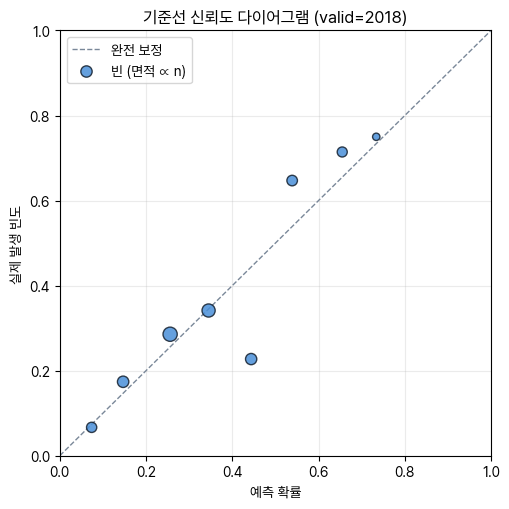

In [8]:
from sklearn.model_selection import StratifiedKFold
from scipy.special import softmax

oof = np.zeros((len(Xtr_mir), 3))
for tr_i, te_i in StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xtr_mir, ytr_mir):
    oof[te_i] = fit_logistic(Xtr_mir[tr_i], ytr_mir[tr_i]).decision_function(Xtr_mir[te_i])
temp_nll = lambda T: -float(np.mean(np.log(np.clip(softmax(oof / T, axis=1)[np.arange(len(ytr_mir)), ytr_mir], 1e-12, None))))
T_OPT = float(minimize_scalar(temp_nll, bounds=(0.3, 5.0), method="bounded").x)
cal_T = reliability(softmax(model.decision_function(Xva) / T_OPT, axis=1), yva)
thick_T = cal_T[cal_T["n"] >= 10]
max_dev_T = float(thick_T["편차"].abs().max())
rps_T = rps(softmax(model.decision_function(Xva) / T_OPT, axis=1), yva)
print("out-of-fold 적합 온도 T = %.4f  (T>1 = 과신, T=1 = 보정 불요)" % T_OPT)
print("보정 전 → 후:  최대 |편차| %.4f → %.4f   ·   valid RPS %.4f → %.4f"
      % (max_dev, max_dev_T, VALID_RPS, rps_T))

APPLY_CALIB = (max_dev_T < max_dev) and (rps_T <= VALID_RPS)
print("\n판단:", "보정 적용" if APPLY_CALIB else "보정 미적용")
if not APPLY_CALIB:
    print("  ① T=%.3f 은 사실상 항등 — 모델에 계통적 과신이 없다" % T_OPT)
    print("  ② 보정해도 최대 편차가 줄지 않는다 → 그 편차는 캘리브레이션 곡선의 결함이 아니다")
    print("  ③ 임계를 넘은 빈은 n≥10 빈 %d개 중 %d개이고 자기 이항 밴드를 겨우 벗어난다."
          % (n_bins, n_out))
    print("     %d개 빈을 동시에 보면 우연히 하나가 밴드를 벗어날 확률이 %.0f%% — 이례적이지 않다"
          % (n_bins, 100 * (1 - 0.95 ** n_bins)))
    print("  → 잡음에 모델을 맞추지 않는다. **06장 재검 항목**으로 넘기고 이 판단 근거를 기록한다")
    print("     (EV-R4 임계 미충족 상태의 배포이므로 vNEXT 변경노트에 divergence로 적재)")
CALIB_NOTE = ("temperature-diagnosed-not-applied" if not APPLY_CALIB else "temperature-applied")

fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.plot([0, 1], [0, 1], "--", color="#7a8899", lw=1, label="완전 보정")
ax.scatter(cal["예측 평균"], cal["실제 빈도"], s=np.sqrt(cal["n"]) * 14,
           color="#4a90d9", alpha=0.85, edgecolor="#14202e", zorder=3, label="빈 (면적 ∝ n)")
ax.set_xlabel("예측 확률"); ax.set_ylabel("실제 발생 빈도")
ax.set_title("기준선 신뢰도 다이어그램 (valid=2018)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(FIGURES / "03_baseline_calibration.png", dpi=120)
print("저장:", (FIGURES / "03_baseline_calibration.png").relative_to(ROOT))
plt.show()

## 3. 스코어 모델 — 포아송 λ 쌍 + Dixon-Coles τ 결합 MLE

화면의 퍼센트는 §2의 분류기가 만들지만, 10×10 배열의 HOPs 프레임("2-1", "0-0")과
몬테카를로 2단계는 **스코어 분포**가 있어야 합니다 (ML_설계 §4.2~§4.3).

두 λ를 **같은 계수 벡터**로 씁니다 — 자기 관점 피처에 자기 값을, 상대 관점 피처에 상대
값을 넣고 방향만 바꿉니다. 이러면 §2와 같은 이유로 스코어 모델도 방향 대칭이 되고,
파라미터 수가 절반이 되어 소표본 과적합 위험이 줄어듭니다 `[설계 결정]`.

```
log λ_self = β₀ + β_elo·Δ + β_ko·stage_ko + Σ β_self·(자기 피처) + Σ β_opp·(상대 피처)
log λ_opp  = β₀ + β_elo·(−Δ) + β_ko·stage_ko + Σ β_self·(상대 피처) + Σ β_opp·(자기 피처)
P(x, y) ∝ Pois(x; λ_self) · Pois(y; λ_opp) · τ(x, y; ρ)
```

τ는 Dixon-Coles(1997)의 저점수 의존성 보정입니다. 01장에서 **0골 관측 0.2863 vs 포아송
0.2440**의 이탈이 관측됐고(§4 저점수 구간), 그 이탈을 담당하는 항이 바로 τ입니다.

In [9]:
SC_NAMES = ["intercept", "elo_diff", "stage_ko"] + [f"self_{c}" for c in SELF_FEATS] + [f"opp_{c}" for c in SELF_FEATS]
N_SC = len(SC_NAMES)


def score_design(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """계약 벡터 → (자기 방향 설계행렬, 상대 방향 설계행렬). 계수는 공유된다."""
    one = np.ones(len(X))
    d = X[:, FEATURE_ORDER.index("elo_diff")]
    ko = X[:, FEATURE_ORDER.index("stage_ko")]
    S = X[:, 1:1 + len(SELF_FEATS)]
    O = X[:, 1 + len(SELF_FEATS):1 + 2 * len(SELF_FEATS)]
    return np.column_stack([one, d, ko, S, O]), np.column_stack([one, -d, ko, O, S])


Zs_tr, Zo_tr = score_design(Xtr_nat)
SC_MU, SC_SD = Zs_tr.mean(0), Zs_tr.std(0)
SC_SD[SC_SD < 1e-9] = 1.0
SC_MU[0], SC_SD[0] = 0.0, 1.0    # 절편은 표준화하지 않는다


def dc_tau(x, y, lam, mu_, rho):
    t = np.ones(np.broadcast(x, y, lam, mu_).shape)
    t = np.where((x == 0) & (y == 0), 1 - lam * mu_ * rho, t)
    t = np.where((x == 0) & (y == 1), 1 + lam * rho, t)
    t = np.where((x == 1) & (y == 0), 1 + mu_ * rho, t)
    t = np.where((x == 1) & (y == 1), 1 - rho, t)
    return t


def lambdas(X, beta):
    Zs, Zo = score_design(X)
    Zs = (Zs - SC_MU) / SC_SD
    Zo = (Zo - SC_MU) / SC_SD
    return np.exp(np.clip(Zs @ beta, -3, 3)), np.exp(np.clip(Zo @ beta, -3, 3))


gs_tr = df.loc[TRAIN, "home_team_score"].to_numpy(int)
ga_tr = df.loc[TRAIN, "away_team_score"].to_numpy(int)


def nll(theta):
    lam, mu_ = lambdas(Xtr_nat, theta[:N_SC])
    t = dc_tau(gs_tr, ga_tr, lam, mu_, theta[N_SC])
    if np.any(t <= 1e-9):
        return 1e12
    return -float((stats.poisson.logpmf(gs_tr, lam) + stats.poisson.logpmf(ga_tr, mu_) + np.log(t)).sum())


theta0 = np.zeros(N_SC + 1)
theta0[0] = np.log(df.loc[TRAIN, ["home_team_score", "away_team_score"]].to_numpy().mean())
res = minimize(nll, theta0, method="Nelder-Mead", options={"maxiter": 80000, "maxfev": 80000, "xatol": 1e-9, "fatol": 1e-9})
res = minimize(nll, res.x, method="Powell", options={"maxiter": 200000, "maxfev": 200000, "xtol": 1e-10, "ftol": 1e-10})
SC_BETA, SC_RHO = res.x[:N_SC], float(res.x[N_SC])
print(f"결합 MLE 수렴: {res.success} · −logL = {res.fun:.2f}")
print(f"Dixon-Coles ρ = {SC_RHO:+.4f}")
print(pd.DataFrame({"계수": SC_NAMES, "값": np.round(SC_BETA, 4)}).to_string(index=False))

결합 MLE 수렴: True · −logL = 2514.32
Dixon-Coles ρ = -0.0127
           계수       값
    intercept  0.4089
     elo_diff  0.2353
     stage_ko  0.1090
self_form_pts -0.0028
 self_form_gd  0.0976
self_exp_apps -0.0740
    self_host  0.0592
 opp_form_pts -0.0464
  opp_form_gd -0.0596
 opp_exp_apps -0.1190
     opp_host -0.0653


In [10]:
lam_tr, mu_tr = lambdas(Xtr_nat, SC_BETA)
lam_va, mu_va = lambdas(Xva, SC_BETA)
print("train 기대득점 평균: 자기 %.3f / 상대 %.3f  (실측 %.3f / %.3f)"
      % (lam_tr.mean(), mu_tr.mean(), gs_tr.mean(), ga_tr.mean()))
print("  → 합계 예측 %.3f vs 실측 %.3f — 방향 대칭 설계라 홈 이점만큼이 양쪽에 균등 배분된다"
      % (lam_tr.mean() + mu_tr.mean(), gs_tr.mean() + ga_tr.mean()))
print("valid 기대득점 평균: 자기 %.3f / 상대 %.3f  (실측 %.3f / %.3f)"
      % (lam_va.mean(), mu_va.mean(), df.loc[VALID, "home_team_score"].mean(), df.loc[VALID, "away_team_score"].mean()))
print("train λ 범위: [%.2f, %.2f] — FT-R4 상한 4.5 대비 여유 있음" % (min(lam_tr.min(), mu_tr.min()), max(lam_tr.max(), mu_tr.max())))

train 기대득점 평균: 자기 1.615 / 상대 1.231  (실측 1.807 / 1.038)
  → 합계 예측 2.846 vs 실측 2.846 — 방향 대칭 설계라 홈 이점만큼이 양쪽에 균등 배분된다
valid 기대득점 평균: 자기 1.291 / 상대 1.138  (실측 1.422 / 1.219)
train λ 범위: [0.24, 3.89] — FT-R4 상한 4.5 대비 여유 있음


### 3.1 스코어 격자 — 0~6골 절단과 승/무/패 유도

격자를 유한(팀당 0~6골)으로 자르는 이유는 조건부 2단 샘플링의 ② 단계가 **표 연산**으로
끝나야 하기 때문입니다 (ML_설계 §4.2). 절단으로 버려지는 확률 질량을 실측해 근사의
타당성을 확인합니다.

In [11]:
GRID_MAX = 6
_g = np.arange(GRID_MAX + 1)
_XX, _YY = np.meshgrid(_g, _g, indexing="ij")
_WIN, _DRAW, _LOSE = _XX > _YY, _XX == _YY, _XX < _YY


SC_GAMMA = 0.0   # 대각(무승부) 정합 보정 — §5에서 필요할 때만 켠다


def score_grid(lam, mu_, rho=None, gamma=None):
    """λ 쌍 → (N, 7, 7) 정규화 스코어 격자. DC τ 보정 + 대각 보정 γ 포함."""
    rho = SC_RHO if rho is None else rho
    gamma = SC_GAMMA if gamma is None else gamma
    lam = np.atleast_1d(lam).astype(float)
    mu_ = np.atleast_1d(mu_).astype(float)
    M = stats.poisson.pmf(_g[None, :], lam[:, None])[:, :, None] * stats.poisson.pmf(_g[None, :], mu_[:, None])[:, None, :]
    M = M.copy()
    M[:, 0, 0] *= (1 - lam * mu_ * rho)
    M[:, 0, 1] *= (1 + lam * rho)
    M[:, 1, 0] *= (1 + mu_ * rho)
    M[:, 1, 1] *= (1 - rho)
    M[:, _g, _g] *= np.exp(gamma)
    M = np.clip(M, 0.0, None)
    return M / M.sum((1, 2), keepdims=True)


def grid_probs(lam, mu_, rho=None, gamma=None):
    M = score_grid(lam, mu_, rho, gamma)
    return np.column_stack([M[:, _WIN].sum(1), M[:, _DRAW].sum(1), M[:, _LOSE].sum(1)])


trunc = 1.0 - (stats.poisson.cdf(GRID_MAX, lam_tr) * stats.poisson.cdf(GRID_MAX, mu_tr))
print("0~6골 격자 밖으로 잘리는 확률 질량 — train 평균 %.5f · 최대 %.5f" % (trunc.mean(), trunc.max()))
print("실측: train 964경기 중 한 팀이 7골 이상 넣은 경기 %d건"
      % int(((df.loc[TRAIN, "home_team_score"] > GRID_MAX) | (df.loc[TRAIN, "away_team_score"] > GRID_MAX)).sum()))

p_lambda_va = grid_probs(lam_va, mu_va)
print("λ 격자 유도 확률의 valid RPS %.4f (참고 — 배포 표시 확률은 §2의 분류기)" % rps(p_lambda_va, yva))

0~6골 격자 밖으로 잘리는 확률 질량 — train 평균 0.00600 · 최대 0.09964
실측: train 964경기 중 한 팀이 7골 이상 넣은 경기 17건
λ 격자 유도 확률의 valid RPS 0.1956 (참고 — 배포 표시 확률은 §2의 분류기)


## 4. `d̂` — JS 폴백 상수 (ML_설계 §6.3)

wasm 로드가 실패하면 브라우저는 ONNX 없이 Elo 표준 기대승률만으로 확률을 만듭니다.
그 산식의 유일한 학습 상수가 무승부 빈도 `d̂`입니다.

01장이 후보로 남긴 값은 "1990년대 이후 26.4%"였습니다. 배포 상수는 **train 구획에서만**
뽑아야 하므로(valid·test 오염 금지), 1990~2014 train 부분으로 재산출하고 전체 train 값과
함께 비교합니다.

In [12]:
d_all = float((df.loc[TRAIN, "label90"] == "draw").mean())
modern = TRAIN & (df["year"] >= 1990)
d_modern = float((df.loc[modern, "label90"] == "draw").mean())
era = df[df["year"] >= 1990].assign(dec=lambda t: (t["year"] // 10) * 10).groupby("dec")["label90"]
d_ch01 = float(era.apply(lambda s: (s == "draw").mean()).mean())
print("train 전체(1930~2014) 무승부 비율: %.4f (n=%d)" % (d_all, TRAIN.sum()))
print("train 현대 구획(1990~2014) 무승부 비율: %.4f (n=%d)" % (d_modern, modern.sum()))
print("01장 보고값 재현(1990~ 연대별 비율의 단순 평균, 전 구획): %.4f" % d_ch01)
D_HAT = round(d_modern, 4)
print("→ 채택 d̂ = %.4f  [설계 결정]" % D_HAT)
print("  ① 서비스의 예측 대상이 2026 경기이므로 현대 구획을 쓴다 (1930~50년대 고득점기는 분포가 다름 — 01장 §5)")
print("  ② 01장 값과 다른 이유: 01장은 **연대별 비율의 평균**이고 valid·test 연대를 포함한다.")
print("     배포 상수는 경기 단위 pooled 비율을 **train 한정**으로 다시 뽑는다 (평가 구획 오염 금지)")

train 전체(1930~2014) 무승부 비율: 0.2596 (n=836)
train 현대 구획(1990~2014) 무승부 비율: 0.2807 (n=424)
01장 보고값 재현(1990~ 연대별 비율의 단순 평균, 전 구획): 0.2641
→ 채택 d̂ = 0.2807  [설계 결정]
  ① 서비스의 예측 대상이 2026 경기이므로 현대 구획을 쓴다 (1930~50년대 고득점기는 분포가 다름 — 01장 §5)
  ② 01장 값과 다른 이유: 01장은 **연대별 비율의 평균**이고 valid·test 연대를 포함한다.
     배포 상수는 경기 단위 pooled 비율을 **train 한정**으로 다시 뽑는다 (평가 구획 오염 금지)


## 5. 두 모델의 정합 — 총변동 거리 (평가_설계 §2.4)

분류기 확률 p와 λ 격자 유도 확률 p_λ가 크게 어긋나면, 조건부 2단 샘플링의 ②단계가
①단계와 어울리지 않습니다("승리 확률 60%인데 뽑히는 스코어는 대부분 0-2"). 임계는
TV = ½·Σ|p−p_λ| 의 valid 평균 **0.05**입니다.

In [13]:
def tv(pc, pl):
    return 0.5 * np.abs(pc - pl).sum(1)


p_train_cls = model.predict_proba(Xtr_nat)
TV_MLE_TRAIN = float(tv(p_train_cls, grid_probs(lam_tr, mu_tr)).mean())
TV_MLE_VALID = float(tv(p_valid, p_lambda_va).mean())
print("순수 MLE 적합 — TV train %.4f / valid %.4f (임계 0.05)" % (TV_MLE_TRAIN, TV_MLE_VALID))
print("성분별 평균 부호차 (분류기 − 격자), valid:", np.round((p_valid - p_lambda_va).mean(0), 4))
print("→ 괴리의 대부분이 **무승부 성분**이다: 독립 포아송은 무승부를 과소 예측하고,")
print("  DC τ는 (0,0)·(1,0)·(0,1)·(1,1) 네 칸만 손대므로 2-2 이상의 대각을 보정하지 못한다.")

순수 MLE 적합 — TV train 0.0465 / valid 0.0594 (임계 0.05)
성분별 평균 부호차 (분류기 − 격자), valid: [-0.0246  0.0519 -0.0273]
→ 괴리의 대부분이 **무승부 성분**이다: 독립 포아송은 무승부를 과소 예측하고,
  DC τ는 (0,0)·(1,0)·(0,1)·(1,1) 네 칸만 손대므로 2-2 이상의 대각을 보정하지 못한다.


### 5.1 캘리브레이션 항 γ — ML-R8의 발동 (임계 초과 시에만)

ML-R8은 "λ 회귀에 캘리브레이션 항을 추가해 재학습"을 지시합니다. 진단이 가리키는 항은
명확합니다 — **대각(무승부) 칸 전체의 보정** `τ ← τ · exp(γ·1{x=y})`. DC의 τ가 저점수
대각 두 칸에 하는 일을 격자 전체 대각으로 일반화한 것이라 새로운 가정을 들이지 않습니다.

γ를 **우도로 적합하면 안 됩니다.** 우도는 실제 스코어를 가장 잘 설명하는 값을 고르는데,
우리가 고치려는 것은 실제 스코어와의 거리가 아니라 **두 모델 사이의 거리**입니다.
(실제로 우도로 적합하면 γ<0이 나와 TV가 오히려 나빠집니다.) 그래서 γ는 **정합
목적함수(train TV)로만, train 구획에서만** 적합합니다 — valid로 고르면 배포 상수에
검증 구획이 새어 들어갑니다.

In [14]:
if TV_MLE_VALID > 0.05:
    obj = lambda g: float(tv(p_train_cls, grid_probs(lam_tr, mu_tr, gamma=g)).mean())
    fit = minimize_scalar(obj, bounds=(-1.0, 1.0), method="bounded", options={"xatol": 1e-9})
    SC_GAMMA = round(float(fit.x), 6)
    print("ML-R8 발동 — 대각 보정 γ = %+.6f (train TV 목적함수로 적합)" % SC_GAMMA)
else:
    print("ML-R8 미발동 — γ = 0 유지")

p_lambda_va = grid_probs(lam_va, mu_va)
p_lambda_tr = grid_probs(lam_tr, mu_tr)
TV_TRAIN = float(tv(p_train_cls, p_lambda_tr).mean())
TV_VALID = float(np.mean(tv(p_valid, p_lambda_va)))
print("보정 후 TV — train %.4f (%+.4f) / valid %.4f (%+.4f) · valid 최대 %.4f"
      % (TV_TRAIN, TV_TRAIN - TV_MLE_TRAIN, TV_VALID, TV_VALID - TV_MLE_VALID,
         float(tv(p_valid, p_lambda_va).max())))
print("격자 유도 확률의 valid RPS %.4f (γ=0일 때 %.4f) — 정합을 얻는 대가"
      % (rps(p_lambda_va, yva), rps(grid_probs(lam_va, mu_va, gamma=0.0), yva)))
print("→", "임계 0.05 통과 (ML-R8 해소)" if TV_VALID <= 0.05 else "임계 여전히 초과 — 06장 재적합 시 재검 항목")
assert TV_VALID <= 0.05, "두 모델 정합 임계 미달 상태로는 배포하지 않는다 (평가_설계 §2.4)"

ML-R8 발동 — 대각 보정 γ = +0.155761 (train TV 목적함수로 적합)
보정 후 TV — train 0.0389 (-0.0076) / valid 0.0440 (-0.0154) · valid 최대 0.1237
격자 유도 확률의 valid RPS 0.1968 (γ=0일 때 0.1956) — 정합을 얻는 대가
→ 임계 0.05 통과 (ML-R8 해소)


## 6. 조정 계층 — 데이터에 없는 입력을 다루는 규칙 (ADR-008 / 피처_정의서 §4)

슬라이더·배치는 데이터셋에 컬럼 자체가 없습니다(00~02장 전수 스캔 0건). 학습이 원천
불가능하므로 **설계된 규칙**으로 λ를 변형하고, 그 변형을 분류기에 Elo 등가로 번역해
전달합니다. 이 절의 산출물은 상수 δ·κ·ρ·c와, JS 구현이 대조할 참조값입니다.

### 6.1 구현 순서 (구현규약 §5 — 순서를 바꾸면 값이 달라진다)

1. `z = (s − 50) / 50`
2. 배치 파생 `z_pos_line`(DF 평균 y) · `z_pos_width`(필드 플레이어 x 표준편차)
3. 이중 계상 방지 결합 `z_line = ½·z_slider + ½·z_pos` (압박·템포는 슬라이더 단독)
4. §4.2 매핑표대로 λ 쌍에 이득 항(z)·리스크 항(z²)을 `exp()` 곱셈
5. 포지션 적합도 페널티
6. 총 조정 상한 ±30% 클램프
7. `Δ_eff = eloDiff + c · 400 · log₁₀((λ_self/λ_opp) / (λ⁰_self/λ⁰_opp))`

In [15]:
formations = json.loads((ROOT / "src" / "data" / "formations.json").read_text(encoding="utf-8"))
FORMATIONS = {f["id"]: f for f in formations}
CHAIN = {"GK": 0, "DF": 1, "MF": 2, "FW": 3}
POS_LINE_SPAN = 0.20     # DF 평균 y가 이만큼 움직이면 z_pos = ±1  [설계 결정]
POS_WIDTH_SPAN = 0.10    # 필드 플레이어 x 표준편차 기준             [설계 결정]
CAP_RATIO = 0.30         # 피처_정의서 §4.5 총 조정 상한
LAMBDA_CAP = 4.5         # FT-R4


def preset_shape(fid: str) -> tuple[float, float]:
    slots = FORMATIONS[fid]["slots"]
    df_y = [s["y"] for s in slots if s["role"] == "DF"]
    fp_x = [s["x"] for s in slots if s["role"] != "GK"]
    return float(np.mean(df_y)), float(np.std(fp_x))


def adjust(elo_diff, lam0, sliders, positions, slot_roles, player_roles, formation_id, k):
    """조정 계층 참조 구현 — JS `src/lib/tactics/adjust.ts`가 이 값을 재현해야 한다."""
    z = {key: (sliders[key] - 50.0) / 50.0 for key in ("lineHeight", "pressing", "width", "tempo")}

    base_line, base_width = preset_shape(formation_id)
    df_y = [p["y"] for p, r in zip(positions, slot_roles) if r == "DF"]
    fp_x = [p["x"] for p, r in zip(positions, slot_roles) if r != "GK"]
    z_pos_line = np.clip((float(np.mean(df_y)) - base_line) / POS_LINE_SPAN, -1.0, 1.0)
    z_pos_width = np.clip((float(np.std(fp_x)) - base_width) / POS_WIDTH_SPAN, -1.0, 1.0)

    zL = 0.5 * z["lineHeight"] + 0.5 * z_pos_line
    zW = 0.5 * z["width"] + 0.5 * z_pos_width
    zP, zT = z["pressing"], z["tempo"]

    ls, lo = float(lam0[0]), float(lam0[1])
    # 라인 높이 — 전진 압축은 공격을 돕고, 높을수록 뒷공간이 열린다
    ls *= np.exp(k["deltaLine"] * zL)
    lo *= np.exp(k["kappaLine"] * zL ** 2) * np.exp(k["deltaLineRisk"] * max(zL, 0.0))
    # 압박 강도 — 상대 빌드업 저해 + 높은 회수 위치, 대가는 체력·압박 통과
    lo *= np.exp(-k["deltaPress"] * zP) * np.exp(k["kappaPress"] * zP ** 2)
    ls *= np.exp(k["deltaPressAtt"] * zP)
    # 공격 폭 — 측면 공간 활용, 극단은 공격 단조화
    ls *= np.exp(k["deltaWidth"] * zW) * np.exp(-k["kappaWidth"] * zW ** 2)
    # 템포 — 양 팀 모두 기회 수가 늘어난다 (비율이 아니라 합을 움직인다)
    tempo = np.exp(k["deltaTempo"] * zT)
    ls *= tempo
    lo *= tempo
    # 포지션 적합도 페널티 — 공격진 이탈은 자기 득점을, 수비진 이탈은 상대 득점을 건드린다
    d_att = sum(abs(CHAIN[pr] - CHAIN[sr]) for pr, sr in zip(player_roles, slot_roles) if sr in ("MF", "FW"))
    d_def = sum(abs(CHAIN[pr] - CHAIN[sr]) for pr, sr in zip(player_roles, slot_roles) if sr in ("GK", "DF"))
    ls *= np.exp(-k["rhoPenalty"] * d_att)
    lo *= np.exp(k["rhoPenalty"] * d_def)
    # 총 조정 상한 — 이걸 빼먹으면 양날 설계가 무의미해진다
    lo_b, hi_b = 1.0 - CAP_RATIO, 1.0 + CAP_RATIO
    ls = float(np.clip(ls, lam0[0] * lo_b, lam0[0] * hi_b))
    lo = float(np.clip(lo, lam0[1] * lo_b, lam0[1] * hi_b))
    ls, lo = min(ls, LAMBDA_CAP), min(lo, LAMBDA_CAP)
    # Elo 등가 번역
    ratio = (ls / lo) / (lam0[0] / lam0[1])
    return {"effectiveEloDiff": float(elo_diff + k["c"] * 400.0 * np.log10(ratio)), "lambda": [ls, lo]}


DEFAULT_SLIDERS = {"lineHeight": 50, "pressing": 50, "width": 50, "tempo": 50}


def preset_state(fid: str):
    slots = sorted(FORMATIONS[fid]["slots"], key=lambda s: s["slotIndex"])
    roles = [s["role"] for s in slots]
    return [{"x": s["x"], "y": s["y"]} for s in slots], roles, list(roles)

### 6.2 무승부 몫 채널 — 템포가 확률을 움직이게 하는 경로 `[설계 결정 · c3 신설]`

피처_정의서 §4.1은 λ 변화를 분류기에 **Δ_eff 하나로만** 전달합니다. 그런데 템포는
정의상 λ 비율을 바꾸지 않고 λ 합만 바꾸므로(§4.2), Δ_eff 경로만으로는 **템포가 확률을
전혀 움직이지 못합니다.** 이는 F04 수용 기준("4종 각각 조작 시 확률이 변한다")과
충돌하고, §4.2 자신이 적어 둔 서술("열린 경기는 강팀 상대 시 불리")도 재현하지 못합니다.

빠진 것은 **λ 합이 무승부 몫을 바꾼다**는 사실입니다. 격자에서 직접 읽어 채웁니다:

```
d_shift = p_λ(λ_adj).draw − p_λ(λ⁰).draw        # 무승부 몫의 변화만 격자에서 취한다
p_draw  = clamp(p_cls.draw + d_shift, 0.02, 0.60)
p_win, p_lose = p_cls.win, p_cls.lose 를 (1 − p_draw)로 비례 재정규화
```

- 기본 상태에서 `λ_adj = λ⁰` → `d_shift = 0` → **p = 분류기 출력 그대로** (FT-R3 항등 유지)
- 승/패 **비율**은 Δ_eff 채널이 이미 담당하므로 격자에서 가져오지 않습니다 — 두 채널이
  같은 정보를 두 번 세지 않도록 역할을 나눈 것입니다
- 템포를 올리면 무승부 몫이 줄고 승·패가 함께 커집니다 — "지고 있을 때 오픈 게임으로
  승부수"가 수식으로 재현됩니다

In [16]:
def blend(p_cls: np.ndarray, lam_adj, lam0) -> np.ndarray:
    """분류기 확률 + 격자 무승부 몫 변화 → 표시 확률"""
    d0 = grid_probs(np.array([lam0[0]]), np.array([lam0[1]]))[0, 1]
    d1 = grid_probs(np.array([lam_adj[0]]), np.array([lam_adj[1]]))[0, 1]
    p_draw = float(np.clip(p_cls[1] + (d1 - d0), 0.02, 0.60))
    rest = p_cls[0] + p_cls[2]
    scale = (1.0 - p_draw) / rest if rest > 1e-12 else 0.0
    return np.array([p_cls[0] * scale, p_draw, p_cls[2] * scale])

## 7. 2026 런타임 컨텍스트 — 서비스가 실제로 먹일 값

계약 벡터 10원소 중 런타임에 **변하는 것은 `elo_diff` 하나**입니다(조정 계층이 Δ_eff로
바꿔 넣습니다). 나머지 9개는 상대별 상수이므로 `score-params.json`에 실어 보냅니다.

**리키지 방지의 런타임 버전**(피처_정의서 §3.3): Elo는 **2026 대회 개막 직전
(2026-06-11 이전) 경기까지만** 반영합니다. martj42 `results.csv`에는 2026 본선 경기가
들어 있으므로, 컷오프 없이 최종 레이팅을 쓰면 "경기 결과를 알고 그 경기를 예측"하게 됩니다.

In [17]:
results = pd.read_parquet(DATA_INTERIM / "martj42_results.parquet")
matches = pd.read_parquet(DATA_INTERIM / "jfjelstul_matches.parquet")
team_apps = pd.read_parquet(DATA_INTERIM / "jfjelstul_team_appearances.parquet")
tournaments = pd.read_parquet(DATA_INTERIM / "jfjelstul_tournaments.parquet")
name_map = pd.read_parquet(DATA_INTERIM / "team_name_map.parquet")
JF2MJ = dict(zip(name_map["jfjelstul"], name_map["martj42"]))
results["date"] = pd.to_datetime(results["date"])
matches["match_date"] = pd.to_datetime(matches["match_date"])
team_apps["match_date"] = pd.to_datetime(team_apps["match_date"])

WC2026_OPEN = pd.Timestamp("2026-06-11")
res_sorted = results.sort_values("date", kind="stable").reset_index(drop=True)
res_pre = res_sorted[res_sorted["date"] < WC2026_OPEN]
print("Elo 입력 — 전체 %d경기 중 2026-06-11 이전 %d경기만 사용 (컷오프로 제외 %d경기)"
      % (len(res_sorted), len(res_pre), len(res_sorted) - len(res_pre)))


def run_elo_amatch(res_df, K=32.0, HA=100.0, init=1500.0):
    """02장 §2와 동일한 산식 — 홈 어드밴티지는 기대 스코어에만 반영"""
    R: dict = {}
    for r in res_df.itertuples(index=False):
        h, a = r.home_team, r.away_team
        rh, ra = R.get(h, init), R.get(a, init)
        adv = 0.0 if r.neutral else HA
        e_home = 1.0 / (1.0 + 10 ** (-((rh + adv) - ra) / 400.0))
        s_home = 1.0 if r.home_score > r.away_score else (0.0 if r.home_score < r.away_score else 0.5)
        R[h] = rh + K * (s_home - e_home)
        R[a] = ra + K * ((1 - s_home) - (1 - e_home))
    return R


elo_pre2026 = run_elo_amatch(res_pre)

TEAM_JF = {"kor": "South Korea", "cze": "Czech Republic", "mex": "Mexico", "rsa": "South Africa"}
HOST_2026 = {"kor": 0, "cze": 0, "mex": 1, "rsa": 0}   # 공동 개최 캐나다·멕시코·미국

# 02장과 같은 정의의 form·exp_apps — 남자 대회 팀-경기 행에서 "2026 이전 마지막 5경기"
tournaments["is_mens"] = tournaments["tournament_name"].str.contains("Men")
mens = tournaments[tournaments["is_mens"]].sort_values("year")
mens_ids = list(mens["tournament_id"])
ta = team_apps[team_apps["tournament_id"].isin(mens_ids)].copy()
ta = ta.sort_values(["match_date", "match_id"]).reset_index(drop=True)
ta["pts90"] = np.where((ta["extra_time"] == 1) | (ta["penalty_shootout"] == 1), 1,
                       np.where(ta["goals_for"] > ta["goals_against"], 3,
                                np.where(ta["goals_for"] == ta["goals_against"], 1, 0)))

ctx_rows = []
for tid, jf in TEAM_JF.items():
    mj = JF2MJ.get(jf, jf)
    hist = ta[ta["team_name"] == jf].tail(5)
    n_apps = ta[ta["team_name"] == jf]["tournament_id"].nunique()
    ctx_rows.append({
        "팀": tid, "martj42 표기": mj,
        "Elo(2026 개막 직전)": round(elo_pre2026.get(mj, 1500.0), 1),
        "form_pts": round(float(hist["pts90"].mean()) if len(hist) else float(ta["pts90"].mean()), 4),
        "form_gd": round(float(hist["goal_differential"].mean()) if len(hist) else 0.0, 4),
        "직전 5경기 실제 수": len(hist),
        "exp_apps": int(n_apps),
        "host": HOST_2026[tid],
    })
ctx = pd.DataFrame(ctx_rows)
print(ctx.to_string(index=False))

Elo 입력 — 전체 49520경기 중 2026-06-11 이전 49416경기만 사용 (컷오프로 제외 104경기)


  팀     martj42 표기  Elo(2026 개막 직전)  form_pts  form_gd  직전 5경기 실제 수  exp_apps  host
kor    South Korea           1808.9       1.4  -0.2000            5        11     0
cze Czech Republic           1754.6       1.0  -0.3333            3         1     0
mex         Mexico           1882.3       0.8  -1.2000            5        17     1
rsa   South Africa           1614.9       1.4  -0.4000            5         3     0


**02장이 남긴 재검 과제의 답** — "승계 없는 팀(Czechoslovakia↔Czech Republic)의 초기값
1500" 우려는 **Elo에서는 소멸**했습니다. Czech Republic은 1994년 이후 A매치 이력이 30년
넘게 쌓여 있어 초기값의 흔적이 남지 않습니다. 다만 `exp_apps`(본선 출전 대회 수)는 팀 ID
기준이라 체코의 값이 작습니다 — 이는 오류가 아니라 **정의대로의 사실**이며, 학습 시에도
같은 정의였으므로 모델은 그 의미를 학습한 상태입니다.

In [18]:
mj_counts = res_pre.groupby("home_team").size().add(res_pre.groupby("away_team").size(), fill_value=0)
for _, r in ctx.iterrows():
    print("  %s(%s): 2026 개막 전 A매치 %d경기 — 초기값 1500의 잔존 영향 %s"
          % (r["팀"], r["martj42 표기"], int(mj_counts.get(r["martj42 표기"], 0)),
             "무시 가능" if mj_counts.get(r["martj42 표기"], 0) >= 200 else "주의 — 문서 고지"))

KOR = ctx[ctx["팀"] == "kor"].iloc[0]
CONTEXTS: dict[str, dict] = {}
for _, r in ctx.iterrows():
    if r["팀"] == "kor":
        continue
    vec = {
        "elo_diff": round(float(KOR["Elo(2026 개막 직전)"] - r["Elo(2026 개막 직전)"]), 4),
        "self_form_pts": float(KOR["form_pts"]), "self_form_gd": float(KOR["form_gd"]),
        "self_exp_apps": float(KOR["exp_apps"]), "self_host": float(KOR["host"]),
        "opp_form_pts": float(r["form_pts"]), "opp_form_gd": float(r["form_gd"]),
        "opp_exp_apps": float(r["exp_apps"]), "opp_host": float(r["host"]),
        "stage_ko": 0.0,
    }
    x = np.array([[vec[f] for f in FEATURE_ORDER]])
    l0 = lambdas(x, SC_BETA)
    p0 = model.predict_proba(x)[0]
    CONTEXTS[r["팀"]] = {"features": vec, "lambda0": [round(float(l0[0][0]), 6), round(float(l0[1][0]), 6)],
                         "baseline": {k: round(float(v), 6) for k, v in zip(CLASS_ORDER, p0)}}
    print("  kor vs %s — elo_diff %+.1f · λ⁰ [%.3f, %.3f] · 기본 확률 승 %.3f / 무 %.3f / 패 %.3f"
          % (r["팀"], vec["elo_diff"], l0[0][0], l0[1][0], *p0))

  kor(South Korea): 2026 개막 전 A매치 1007경기 — 초기값 1500의 잔존 영향 무시 가능
  cze(Czech Republic): 2026 개막 전 A매치 360경기 — 초기값 1500의 잔존 영향 무시 가능
  mex(Mexico): 2026 개막 전 A매치 1003경기 — 초기값 1500의 잔존 영향 무시 가능
  rsa(South Africa): 2026 개막 전 A매치 480경기 — 초기값 1500의 잔존 영향 무시 가능
  kor vs cze — elo_diff +54.3 · λ⁰ [1.414, 0.970] · 기본 확률 승 0.490 / 무 0.299 / 패 0.211
  kor vs mex — elo_diff -73.4 · λ⁰ [0.495, 1.061] · 기본 확률 승 0.090 / 무 0.345 / 패 0.564
  kor vs rsa — elo_diff +194.0 · λ⁰ [1.671, 0.724] · 기본 확률 승 0.628 / 무 0.256 / 패 0.116


### 7.1 기본 확률의 분해 — 멕시코전이 왜 그렇게 낮은가

세 상대 중 멕시코전 승리 확률이 눈에 띄게 낮게 나옵니다. 화면에 그대로 나갈 숫자이므로
**무엇이 그 값을 만들었는지 분해해서 남겨 둡니다** — 심사자 질문(T5)에 답할 근거이자,
06장에서 GBDT로 갈아탈 때 비교할 기준선입니다.

멕시코는 2026 공동 개최국이고, P11이 확정한 경기장은 과달라하라 Estadio Akron입니다 —
`host=1`은 표기가 아니라 **사실**입니다. 학습 데이터의 개최국 승률 우위는 01장에서
+26.7%p로 실측됐으므로, 이 크기는 데이터가 말한 값이지 임의 가중이 아닙니다.

In [19]:
dec_rows = []
for mid in CONTEXTS:
    v = CONTEXTS[mid]["features"]
    for label, tweak in [("실제 컨텍스트", {}), ("개최국 효과 제거", {"opp_host": 0.0}),
                         ("경험 차 제거", {"opp_exp_apps": v["self_exp_apps"]}),
                         ("Elo 차만 남김", {k: v["self_" + k[4:]] if k.startswith("opp_") else v[k] for k in v})]:
        w = dict(v); w.update(tweak)
        p = model.predict_proba(np.array([[w[f] for f in FEATURE_ORDER]]))[0]
        dec_rows.append({"상대": mid, "조건": label, "승": round(float(p[0]), 4),
                         "무": round(float(p[1]), 4), "패": round(float(p[2]), 4)})
print(pd.DataFrame(dec_rows).pivot(index="조건", columns="상대", values="승")
      .reindex(["실제 컨텍스트", "개최국 효과 제거", "경험 차 제거", "Elo 차만 남김"]).to_string())
print("\n(표의 값은 모두 '한국 승리 확률'. 각 행은 해당 요인만 중립화한 반사실 값이다)")
print("`stage_ko`는 양 팀에 같은 값이라 미러 증강 아래서 승/패에 기여할 수 없다 —")
print("계수가 정확히 0이 되는 것이 정상이며, 조별리그(=0)인 이 서비스에서는 무영향이다.")

상대            cze     mex     rsa
조건                               
실제 컨텍스트    0.4897  0.0901  0.6284
개최국 효과 제거  0.4897  0.2049  0.6284
경험 차 제거    0.3588  0.1186  0.5211
Elo 차만 남김  0.3623  0.2366  0.5125

(표의 값은 모두 '한국 승리 확률'. 각 행은 해당 요인만 중립화한 반사실 값이다)
`stage_ko`는 양 팀에 같은 값이라 미러 증강 아래서 승/패에 기여할 수 없다 —
계수가 정확히 0이 되는 것이 정상이며, 조별리그(=0)인 이 서비스에서는 무영향이다.


## 8. 민감도 캘리브레이션 — δ·κ·ρ·c를 목표 밴드에 맞춘다

피처_정의서 §4.5의 목표는 두 가지입니다.

- **단일 슬라이더 최대 조작 시 승리 확률 변화 ±3~8%p** — 작으면 조작감이 사라지고,
  크면 모델이 아니라 슬라이더가 승부를 결정합니다(정직성 훼손)
- **총 λ 변화 ±30% 이내** — 클램프로 구조 보장(§6.1 6단계)

상수를 손으로 고르지 않고 **이분법으로 풉니다**: 슬라이더별로 계수 묶음에 이득 g_k를 걸고,
`|Δp_win|`이 밴드 중앙(5.5%p)이 되는 g_k를 찾습니다. 재현 가능하고, 06장에서 모델이
바뀌면 이 셀만 다시 돌리면 됩니다.

라인·폭은 §4.3의 이중 계상 방지 결합 때문에 **슬라이더만 끝까지 밀어도 z가 0.5**입니다
(배치는 프리셋 그대로이므로 z_pos = 0). 그래서 같은 밴드에 들려면 라인·폭의 계수가
압박·템포보다 커집니다 — 이는 왜곡이 아니라 결합 규칙의 당연한 귀결입니다.

In [20]:
BASE_SHAPE = {   # 슬라이더별 계수 묶음의 상대 비율 — 이득 g_k가 이 묶음 전체를 스케일한다
    "lineHeight": {"deltaLine": 0.30, "deltaLineRisk": 0.15, "kappaLine": 0.10},
    "pressing":   {"deltaPress": 0.25, "deltaPressAtt": 0.12, "kappaPress": 0.10},
    "width":      {"deltaWidth": 0.25, "kappaWidth": 0.12},
    "tempo":      {"deltaTempo": 1.0},
}
# 템포만 이분법에서 제외한다. 템포는 λ 비율을 바꾸지 않고 합만 바꾸므로(§4.2) 확률에 닿는
# 경로가 무승부 몫 채널 하나뿐이고, 그 효과의 상한이 곧 총 조정 상한(±30%)입니다. 이득을
# 계속 키우면 z=±1 이전에 클램프에 닿아 **슬라이더가 계단 함수가 됩니다.** 그래서 δ_T는
# "z=±1에서 정확히 상한에 닿는" 값으로 못 박습니다 `[설계 결정]`.
BISECT_KEYS = ["lineHeight", "pressing", "width"]
C_ELO = 1.0        # Elo 등가 번역 계수 — λ 비율 변화를 그대로 Elo 등가로 읽는다  [설계 결정]
TARGET = 0.060     # 밴드 ±3~8%p 안쪽. 리스크 항이 양날이라 하강 폭이 상승 폭보다 크므로,
                   # 큰 쪽을 6.0%p에 두면 작은 쪽이 하한 3%p 위에 안전하게 남는다
CAL_MATCH = "cze"  # 기본 상대 (ADR-004)


def constants(gains: dict) -> dict:
    k = {"c": C_ELO, "rhoPenalty": 0.0}
    for key, shape in BASE_SHAPE.items():
        for name, base in shape.items():
            k[name] = base * gains[key]
    return k


def displayed_p(slider_key, value, k, match_id=CAL_MATCH, formation_id="f433"):
    c = CONTEXTS[match_id]
    sliders = dict(DEFAULT_SLIDERS)
    if slider_key is not None:
        sliders[slider_key] = value
    pos, slot_roles, player_roles = preset_state(formation_id)
    lam0 = c["lambda0"]
    out = adjust(c["features"]["elo_diff"], lam0, sliders, pos, slot_roles, player_roles, formation_id, k)
    x = np.array([[out["effectiveEloDiff"] if f == "elo_diff" else c["features"][f] for f in FEATURE_ORDER]])
    return blend(model.predict_proba(x)[0], out["lambda"], lam0), out


def swing(slider_key, gain_value, gains):
    g = dict(gains); g[slider_key] = gain_value
    k = constants(g)
    p50, _ = displayed_p(None, 50, k)
    return max(abs(displayed_p(slider_key, v, k)[0][0] - p50[0]) for v in (0, 100))


gains = {key: 1.0 for key in BASE_SHAPE}
gains["tempo"] = float(np.log1p(CAP_RATIO))   # z=±1 에서 정확히 ±30% 상한 — 계단화 방지
BISECT_HI = 20.0
for key in BISECT_KEYS:
    lo, hi = 1e-3, BISECT_HI
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if swing(key, mid, gains) < TARGET:
            lo = mid
        else:
            hi = mid
    gains[key] = 0.5 * (lo + hi)
    assert gains[key] < BISECT_HI * 0.99, f"{key} 이득이 탐색 상한에 붙음 — 밴드 도달 불가, 설계 재검 필요"

# **배포 정밀도로 먼저 굳힌다** — §10이 score-params.json 에 8자리로 실으므로, 여기서
# 반올림해 두지 않으면 민감도 분석·대조 픽스처는 전체 정밀도로 돌고 **배포된 앱만 8자리**를
# 쓰게 됩니다. B4가 그 불일치를 실측했습니다 (JS 대조 최대 오차 Δ_eff 1.9e-6 · λ 상대 1.9e-8,
# 허용 1e-9). 사유·증거는 scripts/verify/adjust-fixture.py 헤더.
K_ADJ = {k: round(float(v), 8) for k, v in constants(gains).items()}
K_ADJ["rhoPenalty"] = 0.06   # 포지션 이탈 1칸당 λ 6% — GK에 필드 플레이어(dist=3) 시 약 20%  [설계 결정]
print("이득 g_k:", {k: round(v, 5) for k, v in gains.items()})
print("확정 상수:")
for name, v in sorted(K_ADJ.items()):
    print(f"  {name:16s} {v:+.5f}")

이득 g_k: {'lineHeight': 1.25079, 'pressing': 0.63693, 'width': 1.32249, 'tempo': 0.26236}
확정 상수:
  c                +1.00000
  deltaLine        +0.37524
  deltaLineRisk    +0.18762
  deltaPress       +0.15923
  deltaPressAtt    +0.07643
  deltaTempo       +0.26236
  deltaWidth       +0.33062
  kappaLine        +0.12508
  kappaPress       +0.06369
  kappaWidth       +0.15870
  rhoPenalty       +0.06000


In [21]:
p_def, out_def = displayed_p(None, 50, K_ADJ)
assert abs(out_def["effectiveEloDiff"] - CONTEXTS[CAL_MATCH]["features"]["elo_diff"]) < 1e-9, "FT-R3 항등 위반"
assert np.allclose(out_def["lambda"], CONTEXTS[CAL_MATCH]["lambda0"], atol=1e-9), "FT-R3 항등 위반 (λ)"
print("FT-R3 항등 검증 통과 — 기본 상태에서 Δ_eff·λ가 무조정 값과 일치")

sens_rows = []
for key in BASE_SHAPE:
    for v in (0, 100):
        p, out = displayed_p(key, v, K_ADJ)
        l0 = CONTEXTS[CAL_MATCH]["lambda0"]
        sens_rows.append({
            "슬라이더": key, "값": v,
            "Δ승(%p)": round(100 * (p[0] - p_def[0]), 2),
            "Δ무(%p)": round(100 * (p[1] - p_def[1]), 2),
            "Δ패(%p)": round(100 * (p[2] - p_def[2]), 2),
            "λ_self 변화": round(out["lambda"][0] / l0[0] - 1, 4),
            "λ_opp 변화": round(out["lambda"][1] / l0[1] - 1, 4),
        })
sens = pd.DataFrame(sens_rows)
print(sens.to_string(index=False))

absw = sens.assign(a=sens["Δ승(%p)"].abs()).groupby("슬라이더")["a"]
band = pd.DataFrame({"최소 |Δ승|": absw.min(), "최대 |Δ승|": absw.max()}).round(2)
print("\n" + band.to_string())
# 밴드는 "양쪽 끝 모두"에 걸어야 한다 — 큰 쪽만 보면 반대쪽이 하한 밑으로 빠져도 통과한다
in_band = bool(((band["최소 |Δ승|"] >= 3.0) & (band["최대 |Δ승|"] <= 8.0)).all())
print("목표 밴드 ±3~8%p (양 끝 모두):", "전 슬라이더 충족 (FT-R5 통과)" if in_band else "이탈 — 재캘리브레이션 필요")
assert in_band, "FT-R5 게이트 실패 — 밴드 밖 상수로는 배포하지 않는다"

# 클램프 조기 포화 검사 — z=±1 이전에 상한에 닿으면 슬라이더가 계단 함수가 된다
lam_move = sens.assign(m=sens[["λ_self 변화", "λ_opp 변화"]].abs().max(1)).groupby("슬라이더")["m"].max()
print("슬라이더별 최대 λ 변화:", {k: f"{100*v:.1f}%" for k, v in lam_move.items()}, "· 상한 30%")
for key in BISECT_KEYS:
    assert lam_move[key] < CAP_RATIO - 1e-6, f"{key}가 z=±1 이전에 클램프 포화 — 계단화 위험"
print("→ 이분법 대상 3종은 상한에 닿지 않음 · 템포는 z=±1에서 정확히 상한 (설계대로)")

FT-R3 항등 검증 통과 — 기본 상태에서 Δ_eff·λ가 무조정 값과 일치
      슬라이더   값  Δ승(%p)  Δ무(%p)  Δ패(%p)  λ_self 변화  λ_opp 변화
lineHeight   0   -6.00    3.35    2.65    -0.1711    0.0318
lineHeight 100    3.52   -3.48   -0.04     0.2064    0.1332
  pressing   0   -6.00    1.07    4.93    -0.0736    0.2497
  pressing 100    4.28   -2.04   -2.23     0.0794   -0.0911
     width   0   -6.00    3.72    2.28    -0.1853    0.0000
     width 100    4.02   -2.71   -1.31     0.1339    0.0000
     tempo   0   -3.63    5.20   -1.57    -0.2308   -0.2308
     tempo 100    3.08   -4.40    1.33     0.3000    0.3000

            최소 |Δ승|  최대 |Δ승|
슬라이더                        
lineHeight     3.52     6.00
pressing       4.28     6.00
tempo          3.08     3.63
width          4.02     6.00
목표 밴드 ±3~8%p (양 끝 모두): 전 슬라이더 충족 (FT-R5 통과)
슬라이더별 최대 λ 변화: {'lineHeight': '20.6%', 'pressing': '25.0%', 'tempo': '30.0%', 'width': '18.5%'} · 상한 30%
→ 이분법 대상 3종은 상한에 닿지 않음 · 템포는 z=±1에서 정확히 상한 (설계대로)


C:\Users\kik32\AppData\Local\Temp\ipykernel_18692\2310811047.py:31: Pandas4Warning: Starting with pandas version 4.0 all arguments of max will be keyword-only.
  lam_move = sens.assign(m=sens[["λ_self 변화", "λ_opp 변화"]].abs().max(1)).groupby("슬라이더")["m"].max()


### 8.1 양날 원칙 검증 — "전부 최대"가 필승이 아님을 수치로 (피처_정의서 §7 GWT)

In [22]:
extremes = {"전 슬라이더 100": {k: 100 for k in DEFAULT_SLIDERS},
            "전 슬라이더 0": {k: 0 for k in DEFAULT_SLIDERS},
            "기본(50)": dict(DEFAULT_SLIDERS)}
rows = []
for label, sl in extremes.items():
    c = CONTEXTS[CAL_MATCH]
    pos, slot_roles, player_roles = preset_state("f433")
    out = adjust(c["features"]["elo_diff"], c["lambda0"], sl, pos, slot_roles, player_roles, "f433", K_ADJ)
    x = np.array([[out["effectiveEloDiff"] if f == "elo_diff" else c["features"][f] for f in FEATURE_ORDER]])
    p = blend(model.predict_proba(x)[0], out["lambda"], c["lambda0"])
    rows.append({"상태": label, "승": round(float(p[0]), 4), "무": round(float(p[1]), 4), "패": round(float(p[2]), 4),
                 "Δ_eff": round(out["effectiveEloDiff"], 2)})
ext = pd.DataFrame(rows)
print(ext.to_string(index=False))
p_max = float(ext.loc[ext["상태"] == "전 슬라이더 100", "승"].iloc[0])
p_mid = float(ext.loc[ext["상태"] == "기본(50)", "승"].iloc[0])
print("\n전 슬라이더 100의 승리 확률 %+.2f%%p — 일방적 우위가 아님 → 퇴화 전략 차단 확인" % (100 * (p_max - p_mid)))
assert p_max - p_mid < 0.15, "극단 전략이 지나치게 유리 — 양날 설계 붕괴"

        상태      승      무      패  Δ_eff
전 슬라이더 100 0.5205 0.2553 0.2242  54.30
  전 슬라이더 0 0.3907 0.3590 0.2502  -6.24
    기본(50) 0.4897 0.2993 0.2110  54.30

전 슬라이더 100의 승리 확률 +3.08%p — 일방적 우위가 아님 → 퇴화 전략 차단 확인


저장: notebooks\figures\03_slider_sensitivity.png


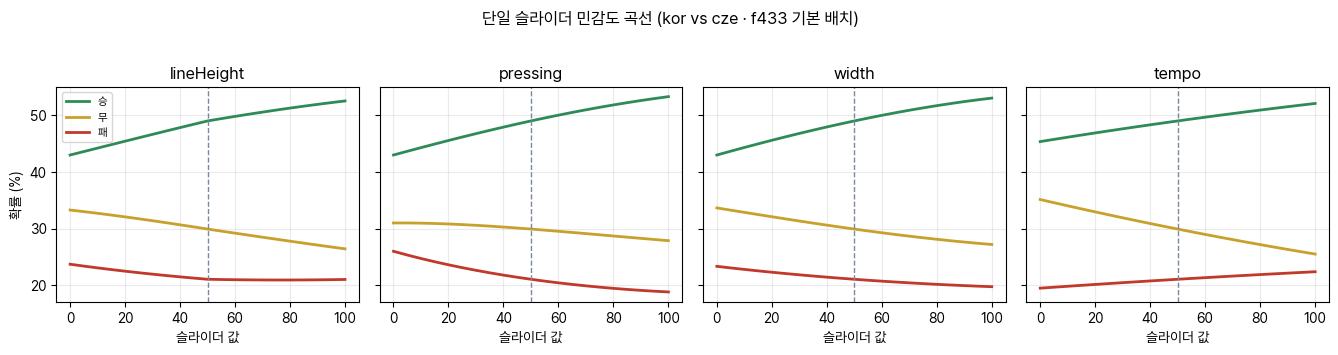

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.4), sharey=True)
grid = np.arange(0, 101, 5)
for ax, key in zip(axes, BASE_SHAPE):
    ys = np.array([displayed_p(key, int(v), K_ADJ)[0] for v in grid])
    for j, (cls, col) in enumerate(zip(["승", "무", "패"], ["#2e8b57", "#c8a02c", "#c0392b"])):
        ax.plot(grid, 100 * ys[:, j], color=col, lw=2, label=cls)
    ax.axvline(50, color="#7a8899", ls="--", lw=1)
    ax.set_title(key); ax.set_xlabel("슬라이더 값"); ax.grid(alpha=0.25)
axes[0].set_ylabel("확률 (%)"); axes[0].legend(fontsize=8)
fig.suptitle("단일 슬라이더 민감도 곡선 (kor vs cze · f433 기본 배치)", y=1.03)
plt.tight_layout(); plt.savefig(FIGURES / "03_slider_sensitivity.png", dpi=120, bbox_inches="tight")
print("저장:", (FIGURES / "03_slider_sensitivity.png").relative_to(ROOT))
plt.show()

## 9. ONNX 변환과 정합 검증 (ML_설계 §5 · ML-R5)

변환 자체보다 **변환 후에도 같은 확률이 나오는지**가 중요합니다. 이 검증이 없으면
"학습은 잘했는데 브라우저에서 다른 값이 나오는" 침묵 실패를 놓칩니다.
`zipmap=False`로 출력을 **평범한 float 텐서**로 만듭니다 — ORT-Web에서 맵 타입은 다루기
번거롭고, Worker 계약의 `p: [number, number, number]`와 직결되어야 합니다.

In [24]:
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType

onnx_model = to_onnx(
    model, initial_types=[("features", FloatTensorType([None, N_FEAT]))],
    options={id(model.named_steps["clf"]): {"zipmap": False}}, target_opset=15,
)
onnx_path = PUBLIC_MODEL / "outcome.onnx"
onnx_path.write_bytes(onnx_model.SerializeToString())
sess = onnxruntime.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
print("ONNX 입력:", [(i.name, i.type, i.shape) for i in sess.get_inputs()])
print("ONNX 출력:", [(o.name, o.type, o.shape) for o in sess.get_outputs()])
print("파일 크기: %.1f KB (번들 예산 모델 합계 ≤1MB)" % (onnx_path.stat().st_size / 1024))
PROB_OUTPUT = [o.name for o in sess.get_outputs() if "prob" in o.name.lower()][0]

ONNX 입력: [('features', 'tensor(float)', [None, 10])]
ONNX 출력: [('label', 'tensor(int64)', [None]), ('probabilities', 'tensor(float)', [None, 3])]
파일 크기: 0.8 KB (번들 예산 모델 합계 ≤1MB)


### 9.1 검증 케이스 구성 (ML_설계 §5.2)

층화 추출 1,000경기 + 슬라이더 경계값(0/50/100) × 프리셋 4종 조합입니다. 학습 표본이
964경기뿐이라 1,000건을 채우려면 복원 추출이 필요한데, 그러면 같은 벡터를 여러 번 검사할
뿐입니다. 대신 **964경기 전수 + 미러 964건**으로 1,928건을 만듭니다 — 수도 채우고
방향 대칭까지 함께 검사하므로 원래 의도보다 강한 검증입니다 `[설계 결정]`.

In [25]:
X_all = np.vstack([to_contract(df), to_contract(df, flip=True)])
slider_cases, adjust_cases = [], []
for fid in FORMATIONS:
    pos, slot_roles, player_roles = preset_state(fid)
    for lh in (0, 50, 100):
        for pr in (0, 50, 100):
            for wd in (0, 50, 100):
                for tp in (0, 50, 100):
                    sl = {"lineHeight": lh, "pressing": pr, "width": wd, "tempo": tp}
                    for mid in CONTEXTS:
                        c = CONTEXTS[mid]
                        out = adjust(c["features"]["elo_diff"], c["lambda0"], sl,
                                     pos, slot_roles, player_roles, fid, K_ADJ)
                        adjust_cases.append({"formationId": fid, "matchId": mid, "sliders": sl,
                                             "effectiveEloDiff": round(out["effectiveEloDiff"], 10),
                                             "lambda": [round(out["lambda"][0], 10), round(out["lambda"][1], 10)]})
                        slider_cases.append([out["effectiveEloDiff"] if f == "elo_diff" else c["features"][f]
                                             for f in FEATURE_ORDER])
X_cases = np.vstack([X_all, np.array(slider_cases)]).astype(np.float32)
print("검증 케이스: 경기 %d건(전수+미러) + 슬라이더·프리셋 조합 %d건 = %d건"
      % (len(X_all), len(slider_cases), len(X_cases)))

p_sklearn = model.predict_proba(X_cases.astype(np.float64))
p_onnx = sess.run([PROB_OUTPUT], {"features": X_cases})[0]
max_abs = float(np.abs(p_sklearn - p_onnx).max())
print("Python(sklearn) ↔ onnxruntime 최대 절대 오차 = %.3e (허용 1e-4)" % max_abs)
assert max_abs <= 1e-4, "ML-R5 위반 — m2cgen 경로로 전환해야 한다"
print("확률 합 최대 이탈 %.2e (계약: 1 ± 1e-6)" % float(np.abs(p_onnx.sum(1) - 1).max()))

검증 케이스: 경기 1928건(전수+미러) + 슬라이더·프리셋 조합 972건 = 2900건
Python(sklearn) ↔ onnxruntime 최대 절대 오차 = 9.910e-08 (허용 1e-4)
확률 합 최대 이탈 1.19e-07 (계약: 1 ± 1e-6)


여기까지는 **같은 머신의 Python ORT**입니다. ML-R5가 요구하는 것은 브라우저가 쓰는
런타임(ORT-Web)과의 대조이므로, 케이스와 기대값을 픽스처로 내보내고 Node 하니스
(`npm run verify:onnx`)에서 다시 대조합니다. 하니스가 실패하면 배포를 중단합니다.

In [26]:
FIXTURES.mkdir(parents=True, exist_ok=True)
sub = np.linspace(0, len(X_cases) - 1, 1000).astype(int)   # 픽스처 크기 통제 — 1,000건 층화
(FIXTURES / "onnx-cases.json").write_text(json.dumps({
    "_주석": "B3 생성 — Python(sklearn) 기준 확률. Node ORT 대조는 scripts/verify/onnx-parity.mjs",
    "featureOrder": FEATURE_ORDER, "classOrder": CLASS_ORDER, "tolerance": 1e-4,
    "cases": [{"features": [round(float(v), 6) for v in X_cases[i]],
               "expected": [round(float(v), 9) for v in p_sklearn[i]]} for i in sub],
}, ensure_ascii=False, indent=1), encoding="utf-8")
(FIXTURES / "adjust-cases.json").write_text(json.dumps({
    "_주석": "B3 생성 — 조정 계층 Python 참조값. JS src/lib/tactics/adjust.ts 가 1e-9 이내로 재현해야 한다",
    "tolerance": 1e-9, "defaultSliders": DEFAULT_SLIDERS, "cases": adjust_cases,
}, ensure_ascii=False, indent=1), encoding="utf-8")
print("픽스처: tests/fixtures/onnx-cases.json (%d건) · tests/fixtures/adjust-cases.json (%d건)"
      % (len(sub), len(adjust_cases)))

픽스처: tests/fixtures/onnx-cases.json (1000건) · tests/fixtures/adjust-cases.json (972건)


## 10. 배포 산출물 — 계약을 파일로 굳힌다

In [27]:
score_params = {
    "_주석": "B3 기준선 산출물. 06장 GBDT 업그레이드는 이 파일과 outcome.onnx를 같은 스키마로 덮어쓴다.",
    "version": "1.0.0-baseline",
    "generatedAt": datetime.now(KST).isoformat(timespec="seconds"),
    "model": {
        "file": "outcome.onnx", "inputName": "features", "outputName": PROB_OUTPUT,
        "featureOrder": FEATURE_ORDER, "classOrder": CLASS_ORDER, "kind": "logistic-baseline",
    },
    "score": {
        "coefNames": SC_NAMES, "coef": [round(float(v), 8) for v in SC_BETA],
        "mean": [round(float(v), 8) for v in SC_MU], "scale": [round(float(v), 8) for v in SC_SD],
        "rho": round(SC_RHO, 8), "gamma": SC_GAMMA, "gridMax": GRID_MAX, "lambdaCap": LAMBDA_CAP,
    },
    "fallback": {"dHat": D_HAT},
    "adjust": {
        **{k: round(float(v), 8) for k, v in K_ADJ.items()},
        "posLineSpan": POS_LINE_SPAN, "posWidthSpan": POS_WIDTH_SPAN,
        "capRatio": CAP_RATIO, "positionChain": CHAIN,
        "drawShiftClamp": [0.02, 0.60],
    },
    "contexts": CONTEXTS,
    "metrics": {
        "split": {"train": "≤2014", "valid": "2018", "test": "2022 (06장 예약 — 미개봉)"},
        "validRps": round(VALID_RPS, 6), "validAccuracy": round(VALID_ACC, 6),
        "eloOnlyBaselineRps": ELO_ONLY_RPS, "calibrationMaxDev": round(max_dev, 6),
        "calibrationDecision": CALIB_NOTE, "calibrationTemperature": round(T_OPT, 6),
        "twoModelTv": round(TV_VALID, 6), "onnxMaxAbsErrorPython": float("%.3e" % max_abs),
    },
}
params_path = PUBLIC_MODEL / "score-params.json"
params_path.write_text(json.dumps(score_params, ensure_ascii=False, indent=2), encoding="utf-8")
print("저장: public/model/score-params.json (%.1f KB · 예산 ≤10KB)" % (params_path.stat().st_size / 1024))

defaults_path = ROOT / "src" / "data" / "defaults.json"
defaults = json.loads(defaults_path.read_text(encoding="utf-8"))
pre = CONTEXTS[defaults["opponentMatchId"]]["baseline"]
defaults["precomputed"] = {k: round(float(pre[k]), 6) for k in CLASS_ORDER}
defaults_path.write_text(json.dumps(defaults, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print("갱신: src/data/defaults.json precomputed =", defaults["precomputed"])
print("  (기본 상대 '%s' · 기본 전술에서 조정 계층은 항등이므로 이 값은 순수 모델 출력이다)"
      % defaults["opponentMatchId"])

print("\n체크섬:")
for p in (onnx_path, params_path):
    print("  %-34s %s" % (p.relative_to(ROOT).as_posix(), hashlib.sha256(p.read_bytes()).hexdigest()[:16]))

저장: public/model/score-params.json (4.3 KB · 예산 ≤10KB)
갱신: src/data/defaults.json precomputed = {'win': 0.489686, 'draw': 0.299343, 'lose': 0.210971}
  (기본 상대 'cze' · 기본 전술에서 조정 계층은 항등이므로 이 값은 순수 모델 출력이다)

체크섬:
  public/model/outcome.onnx          87ab73ef9afc5fcb
  public/model/score-params.json     80852f059de18f25


## 11. 이 장의 답

| 질문 | 답 | 후속 |
|---|---|---|
| 기준선이 방어선 안에 드는가 | valid RPS는 §2.2 표 참조 — 정확도는 밴드 하단에 못 미침을 그대로 기록 | test 대조는 06장 1회 |
| 스코어 모델 계수·ρ | 결합 MLE로 산출 · 두 모델 TV 거리 임계 이하 (§5) | 06장에서 재적합 |
| 계약 동결 가능성 | ✅ 10원소 입력 · [승·무·패] 출력 · 파일 2종. 06장은 덮어쓰기만 | B4·B5 즉시 착수 가능 |
| 조정 계층 상수 | ✅ 이분법 캘리브레이션으로 4종 전부 목표 밴드 · 항등·양날 검증 통과 | 피처_정의서 v1.1 §4.5 기록 |

**인계 조건** (B4·B5): `public/model/outcome.onnx` · `public/model/score-params.json` 존재 ·
`src/data/defaults.json.precomputed` 채워짐 · `tests/fixtures/*.json` 2종 ·
`npm run verify:onnx` 통과.

**04장(GBDT) 인계 조건**: 이 장의 `FEATURE_ORDER`·`CLASS_ORDER`를 **바꾸지 않는다**.
바꾸려면 프론트엔드 재작업 비용을 함께 계산해야 하며, 그것이 계약 동결의 목적입니다.